# Purpose of this Post

The objective of this project is to demonstrate a typical clinical trial analysis workflow using CDISC ADaM datasets, including baseline summary, efficacy analyses, and safety evaluations.


본 프로젝트의 목적은 CDISC ADaM 데이터셋을 활용하여 임상시험 분석의 전형적인 workflow(기초 특성 분석, 유효성 분석, 안전성 분석)를 구현하는 것이다.

- Phase 1 1상
    - 건강한 자원자 또는 소수 환자에서 약물의 안전성, 내약성, 약동학 pk를 평가하는 초기시험
- Phase 2 2상
    - 환자 집단에서 약물의 유효성과 적절한 용량을 탐색하는 시험
- Phase 3 3상
    - 대규모 환자에서 약물의 유효성과 안전성을 확증하여 허가를 위한 근거를 마련하는 시험
- Phase 4 4상
    - 시판 후 실제 환경에서 장기 안전성과 효과를 평가하는 사험

# CDISC

> Clinical data Interchange Standards consortium

> a globalm open, multidisciplinary, non-profit organization that has established standards to support the acquistion, exchange, submission and archive of clinical research data and metadata.

- fosterd efficiency
- Complete traceability
- Enhanved innovation
- Improved data quality
- Facilitated data sharing
- Reduced costs
- Increased predictability
- Streamlined processes

# ADaM Analysis Data Model

> The **ADaM (Analysis Data Model)** dataset is a CDISC standard for organizing clinical trial data to support statistical analysis, regulatory reporting, and traceability. Derived from **SDTM (Study Data Tabulation Model)** data, ADaM datasets are designed to be **"analysis-ready"** for generating tables, listings, and figures. They are required by **regulatory agencies like the FDA and PMDA**. 

- Dataset structure 데이터셋 구성 구조
    - ADSL subject level 시험자 단위
    - BDS Basic Data structure 분석 변수 중심
        - ADLB
        - ADVS
        - ADPK
        - ADPP
        - ADPD
        - ADEG
        - ADEX
        - ADCHG
        - ADBASE
    - OCCDS occurence Data 이벤트 발생 데이터
        - ADAE
        - ADCM
        - ADMH

# SDTM Study Data Tabulation Model

> Standardized datasets for organizing clinical trial data

- Domain
    - DM Demographics
    - AE Adverse Events
    - LB Laboratory Test Resutls
    - VS Vital Signs
    - CM Concomitant Mediations
    - DS Disposition(subject completion or discontinuation status)
    - SU Subject Cisits)
    - EX Drug exposure
    - CO comments
    - MH Medical History
    - EG ECG test

# Reference

- [Phase II Alzheimer’s clinical trial Data](https://github.com/cdisc-org/sdtm-adam-pilot-project/tree/master)
    - [adamdata guide](https://github.com/cdisc-org/sdtm-adam-pilot-project/blob/master/updated-pilot-submission-package/900172/m5/datasets/cdiscpilot01/analysis/adam/datasets/dataguide.pdf)
- [Explanation](https://www.lexjansen.com/pharmasug/2012/DS/PharmaSUG-2012-DS18.pdf)

**Methodology**

> This was a prospective, randomized, multi-center, double-blind, placebo-controlled,
parallel-group study. Subjects were randomized equally to placebo, xanomeline low
dose, or xanomeline

**Study Overview**

- Study design: 
    - Phase II randomized clinical trial
    - 3 treatment arms (Placebo / Low dose / High dose)
    - Duration: 26 weeks
    - Population: Mild–moderate Alzheimer’s disease patients
- Primary objectives
    - Evaluate efficacy of active drug vs placebo
    - Assess safety and tolerability
- Endpoints
    - Primary efficacy:
        - ADAS-Cog score
    - Secondary:
        - CIBIC+
        - NPI
    - Safety
        - Adverse events
        - Laboratory tests
        - Vital signs

**Study Objective**

- The objective of the study was to evaluate the efficacy and safety of Xanomeline in patients with Alzheimer’s disease.
- 이 연구의 목적은 알츠하이머병 환자에서 Xanomeline의 유효성과 안전성을 평가하는 것이다.

# Import

In [91]:
import pandas as pd
import numpy as np
import pyreadstat
import os
from pathlib import Path

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

import patsy

from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter

# Data

In [2]:
data_folder = Path("../../../../delete/adam/")

files = [
    "adae.xpt",
    "adlbc.xpt",
    "adlbh.xpt",
    "adlbhy.xpt",
    "adqsadas.xpt",
    "adqscibc.xpt",
    "adqsnpix.xpt",
    "adsl.xpt",
    "adtte.xpt",
    "advs.xpt"
]

In [3]:
data = {}
metadata = {}

In [4]:
for f in files:
    full_path = data_folder / f
    df, meta = pyreadstat.read_xport(full_path)
    
    key = f.replace(".xpt","")
    
    data[key] = df
    metadata[key] = meta
    
    print(f"{f} loaded:", df.shape)

adae.xpt loaded: (1191, 55)
adlbc.xpt loaded: (74264, 46)
adlbh.xpt loaded: (49932, 46)
adlbhy.xpt loaded: (9954, 43)
adqsadas.xpt loaded: (12463, 40)
adqscibc.xpt loaded: (730, 36)
adqsnpix.xpt loaded: (31140, 41)
adsl.xpt loaded: (254, 48)
adtte.xpt loaded: (254, 26)
advs.xpt loaded: (32139, 34)


---

- How could get the information of dataset?

In [5]:
metadata['adsl'].column_names_to_labels

{'STUDYID': 'Study Identifier',
 'USUBJID': 'Unique Subject Identifier',
 'SUBJID': 'Subject Identifier for the Study',
 'SITEID': 'Study Site Identifier',
 'SITEGR1': 'Pooled Site Group 1',
 'ARM': 'Description of Planned Arm',
 'TRT01P': 'Planned Treatment for Period 01',
 'TRT01PN': 'Planned Treatment for Period 01 (N)',
 'TRT01A': 'Actual Treatment for Period 01',
 'TRT01AN': 'Actual Treatment for Period 01 (N)',
 'TRTSDT': 'Date of First Exposure to Treatment',
 'TRTEDT': 'Date of Last Exposure to Treatment',
 'TRTDUR': 'Duration of Treatment (days)',
 'AVGDD': 'Avg Daily Dose (as planned)',
 'CUMDOSE': 'Cumulative Dose (as planned)',
 'AGE': 'Age',
 'AGEGR1': 'Pooled Age Group 1',
 'AGEGR1N': 'Pooled Age Group 1 (N)',
 'AGEU': 'Age Units',
 'RACE': 'Race',
 'RACEN': 'Race (N)',
 'SEX': 'Sex',
 'ETHNIC': 'Ethnicity',
 'SAFFL': 'Safety Population Flag',
 'ITTFL': 'Intent-To-Treat Population Flag',
 'EFFFL': 'Efficacy Population Flag',
 'COMP8FL': 'Completers of Week 8 Population Fl

---

# ADaM Data Explanation

- ADAS-Cog (Alzheimer's Disease Assessment Scale – Cognitive Subscale)
    - ADAS-Cog score

In [6]:
metadata['adqsadas'].column_names_to_labels

{'STUDYID': 'Study Identifier',
 'SITEID': 'Study Site Identifier',
 'SITEGR1': 'Pooled Site Group 1',
 'USUBJID': 'Unique Subject Identifier',
 'TRTSDT': 'Date of First Exposure to Treatment',
 'TRTEDT': 'Date of Last Exposure to Treatment',
 'TRTP': 'Planned Treatment',
 'TRTPN': 'Planned Treatment (N)',
 'AGE': 'Age',
 'AGEGR1': 'Pooled Age Group 1',
 'AGEGR1N': 'Pooled Age Group 1 (N)',
 'RACE': 'Race',
 'RACEN': 'Race (N)',
 'SEX': 'Sex',
 'ITTFL': 'Intent-to-Treat Population Flag',
 'EFFFL': 'Efficacy Population Flag',
 'COMP24FL': 'Completers of Week 24 Population Flag',
 'AVISIT': 'Analysis Visit',
 'AVISITN': 'Analysis Visit (N)',
 'VISIT': 'Visit Name',
 'VISITNUM': 'Visit Number',
 'ADY': 'Analysis Relative Day',
 'ADT': 'Analysis Date',
 'PARAM': 'Parameter',
 'PARAMCD': 'Parameter Code',
 'PARAMN': 'Parameter (N)',
 'AVAL': 'Analysis Value',
 'BASE': 'Baseline Value',
 'CHG': 'Baseline Value',
 'PCHG': 'Percent Change from Baseline',
 'ABLFL': 'ABLFL',
 'ANL01FL': 'Analysi

- Clinician’s Interview-Based Impression of Change

In [7]:
metadata['adqscibc'].column_names_to_labels

{'STUDYID': 'Study Identifier',
 'SITEID': 'Study Site Identifier',
 'SITEGR1': 'Pooled Site Group 1',
 'USUBJID': 'Unique Subject Identifier',
 'TRTSDT': 'Date of First Exposure to Treatment',
 'TRTEDT': 'Date of Last Exposure to Treatment',
 'TRTP': 'Planned Treatment',
 'TRTPN': 'Planned Treatment (N)',
 'AGE': 'Age',
 'AGEGR1': 'Pooled Age Group 1',
 'AGEGR1N': 'Pooled Age Group 1 (N)',
 'RACE': 'Race',
 'RACEN': 'Race (N)',
 'SEX': 'Sex',
 'ITTFL': 'Intent-to-Treat Population Flag',
 'EFFFL': 'Efficacy Population Flag',
 'COMP24FL': 'Completers of Week 24 Population Flag',
 'AVISIT': 'Analysis Visit',
 'AVISITN': 'Analysis Visit (N)',
 'VISIT': 'Visit Name',
 'VISITNUM': 'Visit Number',
 'ADY': 'Analysis Relative Day',
 'ADT': 'Analysis Date',
 'PARAMCD': 'Parameter Code',
 'PARAM': 'Parameter',
 'PARAMN': 'Parameter (N)',
 'AVAL': 'Analysis Value',
 'ANL01FL': 'Analysis Record Flag 01',
 'DTYPE': 'Derivation Type',
 'AWRANGE': 'Analysis Window Valid Relative Range',
 'AWTARGET': 

# Summary

## Analysis Populations

- Population Summary

In [8]:
#| code-fold: true
#| code-summary: "Show Python code"

df = data['adsl']
rows = ['SAFFL','ITTFL','EFFFL']

result = []

for flag in rows:

    ct = pd.crosstab(df[flag], df['ARM']).reindex(['Y','N'], fill_value=0)
    
    pct = ct.div(ct.sum(axis=0), axis=1) * 100
    
    formatted = ct.astype(str) + " (" + pct.round(1).astype(str) + "%)"
    
    total_ct = df[flag].value_counts().reindex(['Y','N'], fill_value=0)
    total_pct = total_ct / len(df) * 100
    
    formatted['Total'] = (
        total_ct.astype(str) + " (" +
        total_pct.round(0).astype(int).astype(str) + "%)"
    )
    
    formatted.index = [f"{flag}={i}" for i in formatted.index]
    
    result.append(formatted)

table = pd.concat(result)

table

ARM,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total
SAFFL=Y,86 (100.0%),84 (100.0%),84 (100.0%),254 (100%)
SAFFL=N,0 (0.0%),0 (0.0%),0 (0.0%),0 (0%)
ITTFL=Y,86 (100.0%),84 (100.0%),84 (100.0%),254 (100%)
ITTFL=N,0 (0.0%),0 (0.0%),0 (0.0%),0 (0%)
EFFFL=Y,79 (91.9%),74 (88.1%),81 (96.4%),234 (92%)
EFFFL=N,7 (8.1%),10 (11.9%),3 (3.6%),20 (8%)


## Demographics and Baseline Characteristics

- Describe comparability of treatment groups

In [9]:
#| code-fold: true
#| code-summary: "Show Python code"

def _fmt_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def _mean_sd(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return ""
    return f"{x.mean():.1f} ({x.std(ddof=1):.1f})"


def _n_pct(n, denom):
    if denom == 0:
        return f"{n} (0.0%)"
    return f"{n} ({100*n/denom:.1f}%)"


def _shapiro_p(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    n = len(x)
    if n < 3:
        return np.nan
    if n > 5000:
        x = x.sample(5000, random_state=1)
    try:
        return stats.shapiro(x).pvalue
    except Exception:
        return np.nan


def _cont_pvalue(df, var, arm_col, normality=True, alpha=0.05):
    groups = []
    for _, sub in df.groupby(arm_col, dropna=False):
        x = pd.to_numeric(sub[var], errors="coerce").dropna().values
        groups.append(x)

    nonempty = [g for g in groups if len(g) > 0]
    if len(nonempty) < 2:
        return (np.nan, "NA")

    if normality:
        ps = []
        for _, sub in df.groupby(arm_col, dropna=False):
            ps.append(_shapiro_p(sub[var]))

        # any NaN (too small n) or any p<=alpha -> Kruskal (conservative)
        if any(pd.isna(p) for p in ps) or any(p <= alpha for p in ps):
            try:
                return (stats.kruskal(*nonempty).pvalue, "Kruskal–Wallis")
            except Exception:
                return (np.nan, "Kruskal–Wallis")
        else:
            try:
                return (stats.f_oneway(*nonempty).pvalue, "ANOVA")
            except Exception:
                return (np.nan, "ANOVA")
    else:
        try:
            return (stats.f_oneway(*nonempty).pvalue, "ANOVA")
        except Exception:
            return (np.nan, "ANOVA")


def _cat_pvalue(df, var, arm_col):
    tab = pd.crosstab(df[var], df[arm_col], dropna=False)

    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return (np.nan, "NA")

    try:
        chi2, p, dof, expected = stats.chi2_contingency(tab.values, correction=False)
    except Exception:
        return (np.nan, "Chi-square")

    # 2x2 and any expected <5 -> Fisher
    if tab.shape == (2, 2) and (expected < 5).any():
        try:
            _, p_f = stats.fisher_exact(tab.values)
            return (p_f, "Fisher’s exact")
        except Exception:
            return (p, "Chi-square")

    return (p, "Chi-square")


def make_table1_adsl(
    df,
    arm_col="ARM",
    continuous=None,
    categorical=None,
    labels=None,
    normality_for_continuous=True,
    include_missing_row=True,
    pct_decimals=1,
    cont_decimals=1,
):
    continuous = continuous or []
    categorical = categorical or []
    labels = labels or {}

    # ARM levels in appearance order (keep NaN last)
    arm_levels = df[arm_col].dropna().unique().tolist()
    if df[arm_col].isna().any():
        arm_levels = arm_levels + [np.nan]

    total_n = len(df)

    # Footnote letters by test
    test_to_letter = {}
    letters = list("123456789")

    def _letter_for(test_name):
        if test_name in ("", "NA", None):
            return ""
        if test_name not in test_to_letter:
            test_to_letter[test_name] = letters[len(test_to_letter)]
        return test_to_letter[test_name]

    def _get_arm_subset(arm):
        if pd.isna(arm):
            return df[df[arm_col].isna()]
        return df[df[arm_col] == arm]

    def _n_pct_fmt(n, denom):
        if denom == 0:
            return f"{n} (0.{ '0'*pct_decimals }%)" if pct_decimals > 0 else f"{n} (0%)"
        fmt = f"{{:.{pct_decimals}f}}"
        return f"{n} ({fmt.format(100*n/denom)}%)"

    def _mean_sd_fmt(x):
        x = pd.to_numeric(x, errors="coerce").dropna()
        if len(x) == 0:
            return ""
        fmt = f"{{:.{cont_decimals}f}}"
        return f"{fmt.format(x.mean())} ({fmt.format(x.std(ddof=1))})"

    rows = []
    index = []

    def _add_row(row_label, values_by_arm, pval=None, test_name=None):
        row = {}
        for arm in arm_levels:
            row[arm] = values_by_arm.get(arm, "")
        row["Total"] = values_by_arm.get("Total", "")
        if pval is None or test_name in ("", "NA", None):
            row["p-value"] = ""
        else:
            lt = _letter_for(test_name)
            row["p-value"] = f"{_fmt_p(pval)}[{lt}]"
        rows.append(row)
        index.append(row_label)

    # --------- CATEGORICAL ---------
    for var in categorical:
        var_label = labels.get(var, var)

        p, test = _cat_pvalue(df, var, arm_col)

        # header row (blank cells + p-value)
        empty_vals = {arm: "" for arm in arm_levels}
        empty_vals["Total"] = ""
        _add_row(var_label, empty_vals, p, test)

        levels = pd.Series(df[var].dropna().unique()).tolist()
        for lvl in levels:
            vals = {}
            for arm in arm_levels:
                sub = _get_arm_subset(arm)
                n = (sub[var] == lvl).sum()
                denom = len(sub)
                vals[arm] = _n_pct_fmt(n, denom)
            vals["Total"] = _n_pct_fmt((df[var] == lvl).sum(), total_n)
            _add_row(f"  {lvl}", vals)

        if include_missing_row:
            vals = {}
            for arm in arm_levels:
                sub = _get_arm_subset(arm)
                n_miss = sub[var].isna().sum()
                denom = len(sub)
                vals[arm] = _n_pct_fmt(n_miss, denom)
            vals["Total"] = _n_pct_fmt(df[var].isna().sum(), total_n)
            # _add_row("  Missing", vals)

    # --------- CONTINUOUS ---------
    for var in continuous:
        var_label = labels.get(var, var)

        vals = {}
        for arm in arm_levels:
            sub = _get_arm_subset(arm)
            vals[arm] = _mean_sd_fmt(sub[var])
        vals["Total"] = _mean_sd_fmt(df[var])

        p, test = _cont_pvalue(df, var, arm_col, normality=normality_for_continuous)
        _add_row(var_label, vals, p, test)

        if include_missing_row:
            vals_m = {}
            for arm in arm_levels:
                sub = _get_arm_subset(arm)
                n_miss = pd.to_numeric(sub[var], errors="coerce").isna().sum()
                denom = len(sub)
                vals_m[arm] = _n_pct_fmt(n_miss, denom)
            vals_m["Total"] = _n_pct_fmt(pd.to_numeric(df[var], errors="coerce").isna().sum(), total_n)
            # _add_row("  Missing", vals_m)

    out = pd.DataFrame(rows, index=index)

    # Rename NaN ARM column if exists
    col_rename = {}
    for arm in arm_levels:
        if pd.isna(arm):
            col_rename[arm] = "Missing ARM"
        else:
            col_rename[arm] = str(arm)
    out = out.rename(columns=col_rename)

    # Footnotes
    letter_to_test = {v: k for k, v in test_to_letter.items()}
    footnotes = [f"{lt} {letter_to_test[lt]}" for lt in sorted(letter_to_test.keys())]

    return out, footnotes


# =========================
# Usage
# =========================
df = data["adsl"]

labels = {
    "SEX": "Sex",
    "AGE": "Age",
    "RACE": "Race",
    "ETHNIC": "Ethnicity",
    "BMIBL": "Baseline BMI (kg/m^2)",
    "HEIGHTBL": "Baseline Height (cm)",
    "WEIGHTBL": "Baseline Weight (kg)",
    "EDUCLVL": "Years of Education",
}

categorical = ["SEX", "RACE", "ETHNIC"]
continuous = ["AGE", "BMIBL", "HEIGHTBL", "WEIGHTBL", "EDUCLVL"]

table1, footnotes = make_table1_adsl(
    df,
    arm_col="ARM",
    continuous=continuous,
    categorical=categorical,
    labels=labels,
    normality_for_continuous=False,
    include_missing_row=True,
    pct_decimals=0, 
    cont_decimals=0,
)

display(table1)

print("Footnotes:")
for f in footnotes:
    print(f)

,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total,p-value
Sex,,,,,0.141[1]
F,53 (62%),40 (48%),50 (60%),143 (56%),
M,33 (38%),44 (52%),34 (40%),111 (44%),
Race,,,,,0.604[1]
WHITE,78 (91%),74 (88%),78 (93%),230 (91%),
BLACK OR AFRICAN AMERICAN,8 (9%),9 (11%),6 (7%),23 (9%),
AMERICAN INDIAN OR ALASKA NATIVE,0 (0%),1 (1%),0 (0%),1 (0%),
Ethnicity,,,,,0.442[1]
HISPANIC OR LATINO,3 (3%),3 (4%),6 (7%),12 (5%),
NOT HISPANIC OR LATINO,83 (97%),81 (96%),78 (93%),242 (95%),


Footnotes:
1 Chi-square
2 ANOVA


## Treatment Exposure

- exposure duration

In [10]:
#| code-fold: true
#| code-summary: "Show Python code"

exposure = data['adsl'].groupby('ARM')['TRTDUR'].agg(
    N='count',
    Mean='mean',
    SD='std',
    Median='median',
    Min='min',
    Max='max'
)

exposure['Mean (SD)'] = exposure['Mean'].round(1).astype(str) + \
                        " (" + exposure['SD'].round(1).astype(str) + ")"

exposure['Median'] = exposure['Median'].round(1)

exposure['Min, Max'] = exposure['Min'].astype(int).astype(str) + \
                       ", " + exposure['Max'].astype(int).astype(str)

exposure = exposure[['N','Mean (SD)','Median','Min, Max']]

total = pd.DataFrame({
    'N':[df['TRTDUR'].count()],
    'Mean (SD)':[f"{df['TRTDUR'].mean():.1f} ({df['TRTDUR'].std():.1f})"],
    'Median':[df['TRTDUR'].median()],
    'Min, Max':[f"{int(df['TRTDUR'].min())}, {int(df['TRTDUR'].max())}"]
}, index=['Total'])

exposure = pd.concat([exposure, total])
exposure

,N,Mean (SD),Median,"Min, Max"
Placebo,86,149.1 (60.3),182.0,"7, 210"
Xanomeline High Dose,84,99.4 (70.6),76.5,"1, 200"
Xanomeline Low Dose,84,99.0 (68.2),82.5,"2, 212"
Total,254,116.1 (70.3),133.5,"1, 212"


- compliance

In [11]:
#| code-fold: true
#| code-summary: "Show Python code"

df = data['adsl']

df['DISCONT'] = df['DISCONFL'].apply(lambda x: 'Discontinued' if x == 'Y' else 'Completed')

ct = pd.crosstab(df['DISCONT'], df['ARM'])

pct = ct.div(ct.sum(axis=0), axis=1) * 100

disc_table = ct.astype(str) + " (" + pct.round(1).astype(str) + "%)"


total_ct = df['DISCONT'].value_counts()

total_pct = total_ct / len(df) * 100

disc_table['Total'] = total_ct.astype(str) + \
                      " (" + total_pct.round(1).astype(str) + "%)"

disc_table

ARM,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total
DISCONT,,,,
Completed,58 (67.4%),27 (32.1%),25 (29.8%),110 (43.3%)
Discontinued,28 (32.6%),57 (67.9%),59 (70.2%),144 (56.7%)


## Efficacy Analysis(Based on Efficacy Population)

In [102]:
#| code-fold: tr.column_names_to_labelse
#| code-summary: "Show Python code"

def mean_change_table_adqs_se(
    df,
    arm_col="TRTP",         
    param_col="PARAM",
    visit_col="AVISIT",
    aval_col="AVAL",
    base_col="BASE",
    flag_col="ANL01FL",      
    pop_flag_col="EFFFL",    
    use_flag=True,
    use_pop_flag=True,
    decimals=2,
):
    d = df.copy()

    # Analysis set filtering
    if use_pop_flag and pop_flag_col in d.columns:
        d = d[d[pop_flag_col] == "Y"]
    if use_flag and flag_col in d.columns:
        d = d[d[flag_col] == "Y"]

    # Summary by ARM x PARAM x VISIT
    grp = d.query('AVISIT!="Baseline"').groupby([arm_col, param_col, visit_col], dropna=False)["CHG"]
    summ = grp.agg(N="count", Mean="mean", SD="std").reset_index()
    summ["SE"] = summ["SD"] / np.sqrt(summ["N"])

    # Format Mean (SE)
    summ["Mean (SE)"] = (
        summ["Mean"].round(decimals).map(lambda x: f"{x:.{decimals}f}")
        + " ("
        + summ["SE"].round(decimals).fillna(0).map(lambda x: f"{x:.{decimals}f}")
        + ")"
    )

    # Pivot Mean(SE)
    wide = summ.pivot_table(
        index=[param_col, visit_col],
        columns=arm_col,
        values="Mean (SE)",
        aggfunc="first"
    )

    # Total column
    grp_tot = d.query('AVISIT!="Baseline"').groupby([param_col, visit_col], dropna=False)["CHG"]
    tot = grp_tot.agg(N="count", Mean="mean", SD="std")
    tot["SE"] = tot["SD"] / np.sqrt(tot["N"])
    tot_fmt = (
        tot["Mean"].round(decimals).map(lambda x: f"{x:.{decimals}f}")
        + " ("
        + tot["SE"].round(decimals).fillna(0).map(lambda x: f"{x:.{decimals}f}")
        + ")"
    )
    # wide["Total"] = tot_fmt

    # N table (optional but useful)
    n_wide = summ.pivot_table(
        index=[param_col, visit_col],
        columns=arm_col,
        values="N",
        aggfunc="first"
    )
    n_wide["Total"] = tot["N"]

    # Visit ordering by AVISITN if available
    if "AVISITN" in d.columns:
        visit_order = (
            d[[visit_col, "AVISITN"]]
            .drop_duplicates()
            .sort_values("AVISITN")
            .set_index(visit_col)["AVISITN"]
            .to_dict()
        )
        visit_order2 = (
            d.query('AVISIT!="Baseline"')[[visit_col, "AVISITN"]]
            .drop_duplicates()
            .sort_values("AVISITN")
            .set_index(visit_col)["AVISITN"]
            .to_dict()
        )
        wide = wide.reset_index()
        wide["__v"] = wide[visit_col].map(visit_order2)
        wide = wide.sort_values([param_col, "__v"]).drop(columns="__v").set_index([param_col, visit_col])

        n_wide = n_wide.reset_index()
        n_wide["__v"] = n_wide[visit_col].map(visit_order)
        n_wide = n_wide.sort_values([param_col, "__v"]).drop(columns="__v").set_index([param_col, visit_col])

    return wide, n_wide, d


# ===== usage =====
adas = data["adqsadas"]

mean_se_table, n_table, adas_used = mean_change_table_adqs_se(
    adas,
    arm_col="TRTP",  
    decimals=2
)

### N table

In [103]:
display(n_table)        # N

TRTP                                              Placebo  \
PARAM                                    AVISIT             
Adas-Cog(11) Subscore                    Week 8        79   
                                         Week 16       79   
                                         Week 24       79   
Attention/Visual Search Task             Week 8        75   
                                         Week 16       65   
                                         Week 24       62   
Commands                                 Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Comprehension Of Spoken Language         Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Constructional Praxis                    Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Delayed Word Recall                      Week 8        78   
                                         Week 16       68   
                                         Week 24       65   
Ideational Praxis                        Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Maze Solution                            Week 8        77   
                                         Week 16       66   
                                         Week 24       62   
Naming Objects And Fingers (Refer To 5 C Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Orientation                              Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Recall Of Test Instructions              Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Spoken Language Ability                  Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Word Finding Difficulty In Spontaneous S Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Word Recall Task                         Week 8        79   
                                         Week 16       68   
                                         Week 24       65   
Word Recognition                         Week 8        77   
                                         Week 16       67   
                                         Week 24       63   

TRTP                                              Xanomeline High Dose  \
PARAM                                    AVISIT                          
Adas-Cog(11) Subscore                    Week 8                     74   
                                         Week 16                    74   
                                         Week 24                    74   
Attention/Visual Search Task             Week 8                     73   
                                         Week 16                    40   
                                         Week 24                    40   
Commands                                 Week 8                     74   
                                         Week 16                    40   
                                         Week 24                    41   
Comprehension Of Spoken Language         Week 8                     74   
                                         Week 16                    40   
                                         Week 24                    41   
Constructional Praxis                    Week 8                     74   
                      

### Mean change from baseline

In [14]:
display(mean_se_table)  # Mean (SE)

TRTP                                                    Placebo  \
PARAM                                    AVISIT                   
Adas-Cog(11) Subscore                    Week 8     0.85 (0.54)   
                                         Week 16    1.96 (0.66)   
                                         Week 24    2.54 (0.65)   
Attention/Visual Search Task             Week 8    -2.13 (0.81)   
                                         Week 16   -1.09 (0.75)   
                                         Week 24   -1.21 (0.95)   
Commands                                 Week 8     0.06 (0.10)   
                                         Week 16    0.13 (0.10)   
                                         Week 24    0.23 (0.11)   
Comprehension Of Spoken Language         Week 8     0.03 (0.07)   
                                         Week 16   -0.03 (0.09)   
                                         Week 24    0.28 (0.12)   
Constructional Praxis                    Week 8    -0.04 (0.10)   
                                         Week 16   -0.06 (0.11)   
                                         Week 24    0.06 (0.12)   
Delayed Word Recall                      Week 8    -0.19 (0.22)   
                                         Week 16   -0.35 (0.25)   
                                         Week 24   -0.18 (0.25)   
Ideational Praxis                        Week 8     0.06 (0.10)   
                                         Week 16    0.19 (0.10)   
                                         Week 24    0.23 (0.12)   
Maze Solution                            Week 8     8.47 (8.10)   
                                         Week 16    9.24 (9.27)   
                                         Week 24  12.77 (10.89)   
Naming Objects And Fingers (Refer To 5 C Week 8    -0.06 (0.09)   
                                         Week 16    0.10 (0.10)   
                                         Week 24    0.02 (0.12)   
Orientation                              Week 8    -0.37 (0.16)   
                                         Week 16    0.09 (0.20)   
                                         Week 24   -0.02 (0.19)   
Recall Of Test Instructions              Week 8     0.05 (0.12)   
                                         Week 16   -0.06 (0.10)   
                                         Week 24    0.14 (0.17)   
Spoken Language Ability                  Week 8     0.11 (0.08)   
                                         Week 16    0.21 (0.09)   
                                         Week 24    0.18 (0.12)   
Word Finding Difficulty In Spontaneous S Week 8     0.08 (0.08)   
                                         Week 16    0.34 (0.11)   
                                         Week 24    0.28 (0.13)   
Word Recall Task                         Week 8     0.09 (0.11)   
                                         Week 16   -0.11 (0.14)   
                                         Week 24   -0.02 (0.11)   
Word Recognition                         Week 8     0.81 (0.30)   
                                         Week 16    0.93 (0.36)   
                                         Week 24    0.71 (0.36)   

TRTP                                             Xanomeline High Dose  \
PARAM                                    AVISIT                         
Adas-Cog(11) Subscore                    Week 8           0.96 (0.42)   
                                         Week 16          1.19 (0.50)   
                                         Week 24          1.47 (0.50)   
Attention/Visual Search Task             Week 8          -1.79 (0.72)   
                                         Week 16          0.08 (0.94)   
                                         Week 24          2.12 (1.31)   
Commands                                 Week 8          -0.12 (0.10)   
                                         Week 16         -0.22 (0.14)   
                                         Week 24         -0.02 (0.12)   
Comprehension Of Spoken Language         Week 8

### ANCOVA(Change from baseline ~ Treatment + Baseline)

- Analysis of Covariance (ANCOVA) was performed to evaluate the treatment effect on the change from baseline in ADAS-Cog scores at each visit.
- The model included treatment group as a fixed effect and baseline ADAS-Cog score as a covariate.
- Least squares (LS) mean differences between each treatment group and placebo were estimated along with their 95% confidence intervals and p-values.

- 공분산분석(ANCOVA)은 각 방문 시점에서 ADAS-Cog 점수의 기저 대비 변화량을 비교하기 위해 수행되었다.
- 모형에는 치료군을 고정효과로 포함하고 기저 ADAS-Cog 점수를 공변량으로 포함하였다.
- 각 치료군과 위약군(placebo) 간의 최소제곱평균(LS mean) 차이와 95% 신뢰구간 및 p-value를 산출하였다.

In [15]:
#| code-fold: true
#| code-summary: "Show Python code"

df = data['adqsadas'].copy()

# analysis population
df = df[(df['EFFFL']=='Y') & (df['ANL01FL']=='Y')]

visits = ['Week 8','Week 16','Week 24']

rows = []

for v in visits:

    d = df[df['AVISIT']==v]

    model = smf.ols("CHG ~ TRTP + BASE", data=d).fit()

    params = model.params
    conf = model.conf_int()
    pvals = model.pvalues

    for trt in params.index:

        if trt.startswith("TRTP"):

            rows.append({
                "Visit": v,
                "Treatment": trt.split("T.")[-1].replace("]",""),
                "LS Mean Difference": round(params[trt],2),
                "95% CI": f"({conf.loc[trt,0]:.2f}, {conf.loc[trt,1]:.2f})",
                "p-value": round(pvals[trt],3)
            })

ancova_table = pd.DataFrame(rows)

ancova_table

,Visit,Treatment,LS Mean Difference,95% CI,p-value
0,Week 8,Xanomeline High Dose,0.41,"(-0.99, 1.80)",0.568
1,Week 8,Xanomeline Low Dose,0.24,"(-1.12, 1.61)",0.728
2,Week 16,Xanomeline High Dose,-0.42,"(-1.98, 1.13)",0.593
3,Week 16,Xanomeline Low Dose,-0.52,"(-2.05, 1.02)",0.509
4,Week 24,Xanomeline High Dose,0.95,"(-0.99, 2.88)",0.339
5,Week 24,Xanomeline Low Dose,-0.19,"(-2.03, 1.65)",0.842


> Across all visits, neither high-dose nor low-dose Xanomeline showed a statistically significant difference compared with placebo.

- The ANCOVA analysis did not show statistically significant differences between the Xanomeline treatment groups and placebo at Week 8, Week 16, or Week 24.
- ANCOVA 분석 결과, Week 8, Week 16 및 Week 24 모든 방문 시점에서 Xanomeline 치료군과 위약군 간 통계적으로 유의한 차이는 관찰되지 않았다.

---

Least squares means (LS means) were estimated from the statistical models to provide adjusted mean estimates for each treatment group.
Unlike simple arithmetic means, LS means account for covariates included in the model (e.g., baseline score) and adjust for potential imbalances between treatment groups.
This allows for a more accurate comparison of treatment effects across groups.

In this study, LS mean changes from baseline in ADAS-Cog scores were estimated for each treatment group at each visit using the fitted statistical model.

최소제곱평균(LS mean)은 통계 모형을 기반으로 각 치료군의 평균을 추정하기 위해 계산되었다.
단순 평균과 달리 LS mean은 모형에 포함된 공변량(예: 기저 점수)을 고려하여 군 간 잠재적인 불균형을 보정한 평균값을 제공한다.
따라서 치료군 간 효과를 보다 정확하게 비교할 수 있다.

본 연구에서는 통계 모형을 이용하여 각 방문 시점에서 치료군별 ADAS-Cog 점수의 기저 대비 변화량에 대한 LS mean을 추정하였다.

---

## Primary endpoint

- adas-cog change from baseline

### MMRM, Mixed Model for Repeated Measures(CHG ~ TRTP * AVISIT + BASE)

- A Mixed-Effects Model for Repeated Measures (MMRM) was used to evaluate longitudinal changes in ADAS-Cog scores over time.
- The model included treatment group, visit, and the treatment-by-visit interaction as fixed effects, with baseline ADAS-Cog score as a covariate.
- Subject was included as a random effect to account for within-subject correlation across repeated measurements.
- Least squares mean changes from baseline were estimated for each treatment group at each visit, and treatment differences versus placebo were reported with corresponding standard errors, 95% confidence intervals, and p-values.

- 시간에 따른 ADAS-Cog 점수 변화를 평가하기 위해 반복측정 혼합효과모형(MMRM)을 적용하였다.
- 모형에는 치료군, 방문 시점, 그리고 치료군과 방문 시점 간 상호작용을 고정효과로 포함하였으며 기저 ADAS-Cog 점수를 공변량으로 포함하였다.
- 개체 내 반복 측정으로 인한 상관성을 고려하기 위해 대상자(subject)를 랜덤효과로 포함하였다.
- 각 방문 시점에서 치료군별 최소제곱평균(LS mean) 변화량을 추정하고, 위약군 대비 치료 효과 차이와 함께 표준오차, 95% 신뢰구간 및 p-value를 산출하였다.

In [16]:
#| code-fold: true
#| code-summary: "Show Python code"

df = data['adqsadas'].copy()

df = df[(df['EFFFL']=='Y') & (df['ANL01FL']=='Y')]

df = df[df['AVISIT'] != 'Baseline']

mm = df[['USUBJID','TRTP','AVISIT','BASE','CHG']].dropna().reset_index(drop=True)

model = smf.mixedlm(
    "CHG ~ TRTP * AVISIT + BASE",
    data=mm,
    groups=mm["USUBJID"]
)

res = model.fit()

print(res.summary())

                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            CHG        
No. Observations:            8198               Method:                        REML       
No. Groups:                  234                Scale:                         299.2140   
Min. group size:             15                 Log-Likelihood:                -35048.3165
Max. group size:             45                 Converged:                     Yes        
Mean group size:             35.0                                                         
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       2.980    0.606   4.915 0.000  1.792  4.169
TRTP[T.Xanomeline High Dos

In [17]:
#| code-fold: true
#| code-summary: "Show Python code"

def _fmt(x, d=2):
    if pd.isna(x):
        return ""
    return f"{x:.{d}f}"

def mmrm_lsmeans_and_diffs_fixedonly(
    res,
    mm,
    arm_col="TRTP",
    visit_col="AVISIT",
    base_col="BASE",
    visits=None,
    treatments=None,
    decimals=2
):
    # levels
    if visits is None:
        visits = list(pd.Series(mm[visit_col].unique()).dropna())
    if treatments is None:
        treatments = list(pd.Series(mm[arm_col].unique()).dropna())

    # keep category order if present
    if pd.api.types.is_categorical_dtype(mm[visit_col]):
        visits = [v for v in mm[visit_col].cat.categories if v in visits]
    else:
        visits = sorted(visits)

    if pd.api.types.is_categorical_dtype(mm[arm_col]):
        treatments = [t for t in mm[arm_col].cat.categories if t in treatments]

    # prediction grid at mean(BASE)
    base_mean = pd.to_numeric(mm[base_col], errors="coerce").mean()

    grid = pd.DataFrame([(t, v) for v in visits for t in treatments], columns=[arm_col, visit_col])
    grid[base_col] = base_mean

    # align categories to training data (important)
    if pd.api.types.is_categorical_dtype(mm[arm_col]):
        grid[arm_col] = pd.Categorical(grid[arm_col], categories=mm[arm_col].cat.categories)
    if pd.api.types.is_categorical_dtype(mm[visit_col]):
        grid[visit_col] = pd.Categorical(grid[visit_col], categories=mm[visit_col].cat.categories)

    # build fixed-effects design matrix using model's design_info
    design_info = res.model.data.design_info
    X = patsy.build_design_matrices([design_info], grid, return_type="dataframe")[0]

    # fixed effects only
    fe_names = list(res.fe_params.index)
    beta = res.fe_params.loc[fe_names].values

    cov_all = res.cov_params()

    # subset covariance to fixed-effect names
    if isinstance(cov_all, pd.DataFrame):
        covb = cov_all.loc[fe_names, fe_names].values
    else:
        # fallback if ndarray; assume fixed effects come first
        covb = np.asarray(cov_all)[:len(fe_names), :len(fe_names)]

    # also align X to fe_names (in case X has extra cols ordering mismatch)
    X = X[fe_names].values

    # LSMeans and SE
    pred = X @ beta
    var_pred = np.einsum("ij,jk,ik->i", X, covb, X)
    se_pred = np.sqrt(np.maximum(var_pred, 0))

    grid_out = grid.copy()
    grid_out["LSMean"] = pred
    grid_out["SE"] = se_pred
    grid_out["LSMean (SE)"] = grid_out["LSMean"].map(lambda x: _fmt(x, decimals)) + \
                              " (" + grid_out["SE"].map(lambda x: _fmt(x, decimals)) + ")"

    lsmean_table = (
        grid_out.pivot(index=visit_col, columns=arm_col, values="LSMean (SE)")
        .loc[visits, treatments]
    )

    # Differences vs placebo (Wald z)
    diffs = []
    # To access each row's X, rebuild as DataFrame with fe_names columns
    X_df = pd.DataFrame(X, columns=fe_names)

    for v in visits:
        idx_v = grid_out[grid_out[visit_col] == v].index

        # placebo row index
        idx_p = grid_out[(grid_out[visit_col] == v) & (grid_out[arm_col] == "Placebo")].index[0]
        x_p = X_df.loc[idx_p].values

        for t in treatments:
            if t == "Placebo":
                continue
            idx_t = grid_out[(grid_out[visit_col] == v) & (grid_out[arm_col] == t)].index[0]
            x_t = X_df.loc[idx_t].values

            c = x_t - x_p
            diff = c @ beta
            se = np.sqrt(np.maximum(c @ covb @ c, 0))
            z = diff / se if se > 0 else np.nan
            p = 2 * (1 - stats.norm.cdf(abs(z))) if pd.notna(z) else np.nan
            ci_low = diff - 1.96 * se
            ci_high = diff + 1.96 * se

            diffs.append({
                "Visit": v,
                "Treatment": t,
                "LS Mean Diff vs Placebo": _fmt(diff, decimals),
                "SE": _fmt(se, decimals),
                "95% CI": f"({_fmt(ci_low, decimals)}, {_fmt(ci_high, decimals)})",
                "p-value": "<0.001" if (pd.notna(p) and p < 0.001) else (_fmt(p, 3) if pd.notna(p) else "")
            })

    diff_table = pd.DataFrame(diffs)
    diff_table["Visit"] = pd.Categorical(diff_table["Visit"], categories=visits, ordered=True)
    diff_table = diff_table.sort_values(["Visit", "Treatment"]).reset_index(drop=True)

    return lsmean_table, diff_table, base_mean


# ===== usage =====
lsmeans, diffs, base_used = mmrm_lsmeans_and_diffs_fixedonly(
    res=res,
    mm=mm,
    arm_col="TRTP",
    visit_col="AVISIT",
    base_col="BASE",
    visits=["Week 8","Week 16","Week 24"],
    decimals=2
)

In [18]:
print(f"BASE fixed at mean(BASE) = {base_used:.2f}\n")

BASE fixed at mean(BASE) = 7.17



In [19]:
display(lsmeans)

TRTP,Placebo,Xanomeline High Dose,Xanomeline Low Dose
AVISIT,,,
Week 16,0.97 (0.60),0.60 (0.76),0.38 (0.74)
Week 24,1.21 (0.61),2.27 (0.75),1.15 (0.69)
Week 8,0.63 (0.56),0.88 (0.58),0.82 (0.56)


> There is no constant pattern by visits.

- reference는 placebo로 설정

In [20]:
display(diffs)

,Visit,Treatment,LS Mean Diff vs Placebo,SE,95% CI,p-value
0,Week 16,Xanomeline High Dose,-0.38,0.97,"(-2.27, 1.52)",0.696
1,Week 16,Xanomeline Low Dose,-0.60,0.95,"(-2.46, 1.27)",0.531
2,Week 24,Xanomeline High Dose,1.06,0.97,"(-0.84, 2.96)",0.276
3,Week 24,Xanomeline Low Dose,-0.07,0.92,"(-1.88, 1.75)",0.944
4,Week 8,Xanomeline High Dose,0.25,0.81,"(-1.33, 1.84)",0.754
5,Week 8,Xanomeline Low Dose,0.19,0.79,"(-1.36, 1.74)",0.807


> Across all visits, neither high-dose nor low-dose Xanomeline showed a statistically significant difference compared with placebo.

- The MMRM analysis showed no statistically significant treatment differences across visits. 
- MMRM 분석에서도 방문 시점 전반에 걸쳐 치료군과 위약군 간 유의한 차이는 확인되지 않았다.

> Overall, the results indicate that Xanomeline did not demonstrate a significant improvement in ADAS-Cog scores compared with placebo.

> 종합적으로 Xanomeline은 위약군 대비 ADAS-Cog 점수 개선 효과를 유의하게 나타내지 못한 것으로 판단된다.

---

In mixed-effects models for repeated measures (MMRM), LS means represent model-based estimates of the mean outcome for each treatment group at each visit.
These estimates incorporate all available longitudinal data and adjust for baseline differences, enabling a robust comparison of treatment effects over time.

반복측정 혼합효과모형(MMRM)에서는 각 방문 시점에서 치료군별 평균 결과를 모형 기반으로 추정한 값이 LS mean이다.
LS mean은 기저값 보정과 반복 측정 데이터를 모두 반영하여 시간에 따른 치료 효과를 보다 안정적으로 비교할 수 있게 한다.

---

## Safety Analysis(Based on Safety Population)

### Adverse Event

In [21]:
#| code-fold: true
#| code-summary: "Show Python code"

def fmt_npct(n, denom, decimals=1):
    if denom == 0:
        return f"{n} (0.{''.join(['0']*decimals)}%)" if decimals > 0 else f"{n} (0%)"
    pct = 100 * n / denom
    return f"{n} ({pct:.{decimals}f}%)"


def get_treatment_levels(df, trt_col="TRTA"):
    return [x for x in df[trt_col].dropna().unique().tolist()]


def make_total_row(df, trt_col="TRTA", usubjid_col="USUBJID"):
    levels = get_treatment_levels(df, trt_col)
    denoms = df[[usubjid_col, trt_col]].drop_duplicates().groupby(trt_col)[usubjid_col].nunique()
    total_n = df[usubjid_col].nunique()
    return levels, denoms, total_n


def build_soc_pt_table(
    df,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1,
    sort_by_total=True
):
    """
    Input df should already be filtered to the right analysis set and deduplicated appropriately.
    Returns a wide table with columns:
    AESOC, AEDECOD, [TRTA groups...], Total
    """
    levels, denoms, total_n = make_total_row(df, trt_col=trt_col, usubjid_col=usubjid_col)

    rows = []

    # total counts by SOC/PT across treatment arms
    soc_total_counts = (
        df.groupby(soc_col)[usubjid_col]
        .nunique()
        .sort_values(ascending=False)
    )

    soc_order = soc_total_counts.index.tolist()

    for soc in soc_order:
        d_soc = df[df[soc_col] == soc].copy()

        # SOC row: unique subjects with any event in SOC
        row_soc = {soc_col: soc, pt_col: ""}
        for trt in levels:
            n = d_soc.loc[d_soc[trt_col] == trt, usubjid_col].nunique()
            row_soc[trt] = fmt_npct(n, denoms.get(trt, 0), decimals)
        row_soc["Total"] = fmt_npct(d_soc[usubjid_col].nunique(), total_n, decimals)
        rows.append(row_soc)

        # PT rows within SOC
        pt_counts = (
            d_soc.groupby(pt_col)[usubjid_col]
            .nunique()
            .sort_values(ascending=False)
        )
        pt_order = pt_counts.index.tolist()

        for pt in pt_order:
            d_pt = d_soc[d_soc[pt_col] == pt].copy()
            row_pt = {soc_col: "", pt_col: pt}
            for trt in levels:
                n = d_pt.loc[d_pt[trt_col] == trt, usubjid_col].nunique()
                row_pt[trt] = fmt_npct(n, denoms.get(trt, 0), decimals)
            row_pt["Total"] = fmt_npct(d_pt[usubjid_col].nunique(), total_n, decimals)
            rows.append(row_pt)

    out = pd.DataFrame(rows)
    return out[[soc_col, pt_col] + levels + ["Total"]]


def build_binary_summary_table(
    df,
    flag_vars,
    label_map=None,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    decimals=1
):
    """
    For variables like AESER, AESCAN, AESCONG, AESDISAB, AESDTH, AESHOSP, AESLIFE, AESOD
    summarize count of subjects with Y.
    """
    label_map = label_map or {}
    levels, denoms, total_n = make_total_row(df, trt_col=trt_col, usubjid_col=usubjid_col)

    rows = []
    for var in flag_vars:
        d = df[df[var] == "Y"].copy()
        row = {"Parameter": label_map.get(var, var)}
        for trt in levels:
            n = d.loc[d[trt_col] == trt, usubjid_col].nunique()
            row[trt] = fmt_npct(n, denoms.get(trt, 0), decimals)
        row["Total"] = fmt_npct(d[usubjid_col].nunique(), total_n, decimals)
        rows.append(row)

    out = pd.DataFrame(rows)
    return out[["Parameter"] + levels + ["Total"]]


# -----------------------------
# ADR condition helper
# -----------------------------
def is_related(series):
    s = series.astype(str).str.upper().str.strip()
    related_vals = {"POSSIBLE", "PROBABLE"}
    return s.isin(related_vals)

adae = data["adae"].copy()

adae_saf = adae[adae["SAFFL"] == "Y"].copy()

teae_soc = adae_saf[
    (adae_saf["TRTEMFL"] == "Y") &
    (adae_saf["AOCCSFL"] == "Y")
].copy()

# PT level: first occurrence within PT
teae_pt = adae_saf[
    (adae_saf["TRTEMFL"] == "Y") &
    (adae_saf["AOCCPFL"] == "Y")
].copy()

teae_base = teae_pt.copy()

teae_table = build_soc_pt_table(
    teae_base,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1
)

adr = adae_saf[
    (adae_saf["TRTEMFL"] == "Y") &
    (adae_saf["AOCCPFL"] == "Y") &
    (is_related(adae_saf["AEREL"]))
].copy()

adr_table = build_soc_pt_table(
    adr,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1
)

serious = adae_saf[
    (adae_saf["TRTEMFL"] == "Y") &
    (adae_saf["AESER"] == "Y")
].copy()

if "AOCC04FL" in serious.columns:
    serious = serious[serious["AOCC04FL"] == "Y"].copy()
else:
    serious = serious.drop_duplicates(subset=["USUBJID", "TRTA", "AESOC", "AEDECOD"])

serious_table = build_soc_pt_table(
    serious,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1
)

serious_table_adr = build_soc_pt_table(
    serious[(is_related(adae_saf["AEREL"]))],
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1
)


death_ae = adae_saf[
    (adae_saf["TRTEMFL"] == "Y") &
    (adae_saf["AESDTH"] == "Y")
].copy()

# no dedicated death occurrence flags in the variable list, so deduplicate manually
death_ae = death_ae.drop_duplicates(subset=["USUBJID", "TRTA", "AESOC", "AEDECOD"])

death_table = build_soc_pt_table(
    death_ae,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1
)

death_table_adr = build_soc_pt_table(
    death_ae[(is_related(adae_saf["AEREL"]))],
    trt_col="TRTA",
    usubjid_col="USUBJID",
    soc_col="AESOC",
    pt_col="AEDECOD",
    decimals=1
)


criteria_vars = [
    "AESER",
    "AESCAN",
    "AESCONG",
    "AESDISAB",
    "AESDTH",
    "AESHOSP",
    "AESLIFE",
    "AESOD"
]

criteria_labels = {
    "AESER": "Serious Event",
    "AESCAN": "Involves Cancer",
    "AESCONG": "Congenital Anomaly or Birth Defect",
    "AESDISAB": "Persistent or Significant Disability/Incapacity",
    "AESDTH": "Results in Death",
    "AESHOSP": "Requires or Prolongs Hospitalization",
    "AESLIFE": "Life-Threatening",
    "AESOD": "Occurred with Overdose"
}

teae_criteria_df = adae_saf[adae_saf["TRTEMFL"] == "Y"].copy()
teae_criteria_df = teae_criteria_df.drop_duplicates(subset=["USUBJID", "TRTA"] + criteria_vars)

teae_criteria_table = build_binary_summary_table(
    teae_criteria_df,
    flag_vars=criteria_vars,
    label_map=criteria_labels,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    decimals=1
)

adr_criteria_df = adae_saf[
    (adae_saf["TRTEMFL"] == "Y") &
    (is_related(adae_saf["AEREL"]))
].copy()
adr_criteria_df = adr_criteria_df.drop_duplicates(subset=["USUBJID", "TRTA"] + criteria_vars)

adr_criteria_table = build_binary_summary_table(
    adr_criteria_df,
    flag_vars=criteria_vars,
    label_map=criteria_labels,
    trt_col="TRTA",
    usubjid_col="USUBJID",
    decimals=1
)

<ipython-input-21-8a30cf7a090b>:179: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  serious[(is_related(adae_saf["AEREL"]))],
<ipython-input-21-8a30cf7a090b>:206: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  death_ae[(is_related(adae_saf["AEREL"]))],


- TEAE SOC/PT Table 

In [22]:
display(teae_table)

,AESOC,AEDECOD,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total
0,GENERAL DISORDERS AND ADMINISTRATION SITE COND...,,21 (32.3%),40 (52.6%),47 (61.0%),108 (49.5%)
1,,APPLICATION SITE PRURITUS,6 (9.2%),22 (28.9%),22 (28.6%),50 (22.9%)
2,,APPLICATION SITE ERYTHEMA,3 (4.6%),15 (19.7%),12 (15.6%),30 (13.8%)
3,,APPLICATION SITE DERMATITIS,5 (7.7%),7 (9.2%),9 (11.7%),21 (9.6%)
4,,APPLICATION SITE IRRITATION,3 (4.6%),9 (11.8%),9 (11.7%),21 (9.6%)
...,...,...,...,...,...,...
248,,HYPERSENSITIVITY,0 (0.0%),0 (0.0%),1 (1.3%),1 (0.5%)
249,HEPATOBILIARY DISORDERS,,1 (1.5%),0 (0.0%),0 (0.0%),1 (0.5%)
250,,HYPERBILIRUBINAEMIA,1 (1.5%),0 (0.0%),0 (0.0%),1 (0.5%)
251,SOCIAL CIRCUMSTANCES,,0 (0.0%),1 (1.3%),0 (0.0%),1 (0.5%)


- ADR SOC/PT Table

In [23]:
display(adr_table)

,AESOC,AEDECOD,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total
0,GENERAL DISORDERS AND ADMINISTRATION SITE COND...,,18 (41.9%),35 (50.0%),43 (60.6%),96 (52.2%)
1,,APPLICATION SITE PRURITUS,6 (14.0%),22 (31.4%),22 (31.0%),50 (27.2%)
2,,APPLICATION SITE ERYTHEMA,3 (7.0%),15 (21.4%),12 (16.9%),30 (16.3%)
3,,APPLICATION SITE DERMATITIS,5 (11.6%),7 (10.0%),9 (12.7%),21 (11.4%)
4,,APPLICATION SITE IRRITATION,3 (7.0%),9 (12.9%),9 (12.7%),21 (11.4%)
...,...,...,...,...,...,...
126,,VENTRICULAR SEPTAL DEFECT,0 (0.0%),0 (0.0%),1 (1.4%),1 (0.5%)
127,RENAL AND URINARY DISORDERS,,0 (0.0%),1 (1.4%),0 (0.0%),1 (0.5%)
128,,MICTURITION URGENCY,0 (0.0%),1 (1.4%),0 (0.0%),1 (0.5%)
129,REPRODUCTIVE SYSTEM AND BREAST DISORDERS,,1 (2.3%),0 (0.0%),0 (0.0%),1 (0.5%)


- Serious TEAE SOC/PT Table
    - AESER='Y'

In [24]:
display(serious_table)

,AESOC,AEDECOD,Xanomeline High Dose,Xanomeline Low Dose,Total
0,NERVOUS SYSTEM DISORDERS,,2 (100.0%),1 (100.0%),3 (100.0%)
1,,SYNCOPE,1 (50.0%),1 (100.0%),2 (66.7%)
2,,PARTIAL SEIZURES WITH SECONDARY GENERALISATION,1 (50.0%),0 (0.0%),1 (33.3%)


- Serious ADR SOC/PT Table
    - AESER='Y'

In [25]:
display(serious_table_adr)

,AESOC,AEDECOD,Xanomeline High Dose,Xanomeline Low Dose,Total
0,NERVOUS SYSTEM DISORDERS,,1 (100.0%),1 (100.0%),2 (100.0%)
1,,SYNCOPE,1 (100.0%),1 (100.0%),2 (100.0%)


- Death AE SOC/PT Table
    - AESDTH='Y'

In [26]:
display(death_table)

,AESOC,AEDECOD,Xanomeline Low Dose,Placebo,Total
0,CARDIAC DISORDERS,,0 (0.0%),1 (50.0%),1 (33.3%)
1,,MYOCARDIAL INFARCTION,0 (0.0%),1 (50.0%),1 (33.3%)
2,GENERAL DISORDERS AND ADMINISTRATION SITE COND...,,1 (100.0%),0 (0.0%),1 (33.3%)
3,,SUDDEN DEATH,1 (100.0%),0 (0.0%),1 (33.3%)
4,PSYCHIATRIC DISORDERS,,0 (0.0%),1 (50.0%),1 (33.3%)
5,,COMPLETED SUICIDE,0 (0.0%),1 (50.0%),1 (33.3%)


- Death ADR SOC/PT Table
    - AESDTH='Y'

In [27]:
display(death_table_adr)

,AESOC,AEDECOD,Placebo,Total
0,CARDIAC DISORDERS,,1 (100.0%),1 (100.0%)
1,,MYOCARDIAL INFARCTION,1 (100.0%),1 (100.0%)


- TEAE Seriousness Criteria Summary

In [28]:
display(teae_criteria_table)

,Parameter,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total
0,Serious Event,0 (0.0%),2 (2.6%),1 (1.3%),3 (1.4%)
1,Involves Cancer,0 (0.0%),1 (1.3%),2 (2.6%),3 (1.4%)
2,Congenital Anomaly or Birth Defect,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
3,Persistent or Significant Disability/Incapacity,0 (0.0%),0 (0.0%),1 (1.3%),1 (0.5%)
4,Results in Death,2 (3.1%),0 (0.0%),1 (1.3%),3 (1.4%)
5,Requires or Prolongs Hospitalization,5 (7.7%),7 (9.2%),7 (9.1%),19 (8.7%)
6,Life-Threatening,2 (3.1%),1 (1.3%),1 (1.3%),4 (1.8%)
7,Occurred with Overdose,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


- ADR Seriousness Criteria Summary

In [29]:
display(adr_criteria_table)

,Parameter,Placebo,Xanomeline High Dose,Xanomeline Low Dose,Total
0,Serious Event,0 (0.0%),1 (1.4%),1 (1.4%),2 (1.1%)
1,Involves Cancer,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
2,Congenital Anomaly or Birth Defect,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
3,Persistent or Significant Disability/Incapacity,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
4,Results in Death,1 (2.3%),0 (0.0%),0 (0.0%),1 (0.5%)
5,Requires or Prolongs Hospitalization,3 (7.0%),4 (5.7%),4 (5.6%),11 (5.9%)
6,Life-Threatening,2 (4.7%),1 (1.4%),0 (0.0%),3 (1.6%)
7,Occurred with Overdose,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


### Laboratory Analysis

#### Mean chang from baseline

- Laboratory Chemistry

In [107]:
adlbc_meanchg, n_table, adlbc_used = mean_change_table_adqs_se(
    data["adlbc"],
    arm_col="TRTP",  
    decimals=2
)

In [108]:
adlbc_meanchg

TRTP                                                                      Placebo  \
PARAM                                              AVISIT                           
Alanine Aminotransferase (U/L)                               Week 2  -2.40 (1.09)   
                                                             Week 4   3.19 (3.87)   
                                                             Week 6   5.83 (8.06)   
                                                             Week 8  -3.93 (1.77)   
                                                            Week 12  -3.17 (5.74)   
...                                                                           ...   
Urate (umol/L) change from previous visit, rela...          Week 12    nan (0.00)   
                                                            Week 16    nan (0.00)   
                                                            Week 20    nan (0.00)   
                                                            Week 24    nan (0.00)   
                                                   End of Treatment    nan (0.00)   

TRTP                                                                Xanomeline High Dose  \
PARAM                                              AVISIT                                  
Alanine Aminotransferase (U/L)                               Week 2         -0.77 (1.26)   
                                                             Week 4          2.00 (2.00)   
                                                             Week 6         -2.60 (1.34)   
                                                             Week 8        16.50 (14.82)   
                                                            Week 12         -1.43 (1.36)   
...                                                                                  ...   
Urate (umol/L) change from previous visit, rela...          Week 12           nan (0.00)   
                                                            Week 16           nan (0.00)   
                                                            Week 20           nan (0.00)   
                                                            Week 24           nan (0.00)   
                                                   End of Treatment           nan (0.00)   

TRTP                                                                Xanomeline Low Dose  
PARAM                                              AVISIT                                
Alanine Aminotransferase (U/L)                               Week 2         0.86 (2.64)  
                                                             Week 4        -2.35 (0.90)  
                                                             Week 6        -3.75 (0.91)  
                                                             Week 8        -1.33 (3.07)  
                                                            Week 12         5.50 (9.96)  
...                                                                                 ...  
Urate (umol/L) change from previous visit, rela...          Week 12          nan (0.00)  
                                                            Week 16          nan (0.00)  
                                                            Week 20          nan (0.00)  
                                                            Week 24          nan (0.00)  
                                                   End of Treatment          nan (0.00)  

[324 rows x 3 columns]

- Laboratory Hematology

In [109]:
adlbh_meanchg, n_table, adlbh_used = mean_change_table_adqs_se(
    data["adlbh"],
    arm_col="TRTP",  
    decimals=2
)

In [110]:
adlbh_meanchg

TRTP                                                                      Placebo  \
PARAM                                              AVISIT                           
Basophils (GI/L)                                             Week 2  -0.03 (0.01)   
                                                             Week 4  -0.03 (0.01)   
                                                             Week 6  -0.03 (0.01)   
                                                             Week 8  -0.02 (0.00)   
                                                            Week 12  -0.04 (0.01)   
...                                                                           ...   
Platelet (GI/L) change from previous visit, rel...          Week 12    nan (0.00)   
                                                            Week 16    nan (0.00)   
                                                            Week 20    nan (0.00)   
                                                            Week 24    nan (0.00)   
                                                   End of Treatment    nan (0.00)   

TRTP                                                                Xanomeline High Dose  \
PARAM                                              AVISIT                                  
Basophils (GI/L)                                             Week 2         -0.01 (0.00)   
                                                             Week 4         -0.01 (0.00)   
                                                             Week 6         -0.01 (0.01)   
                                                             Week 8         -0.01 (0.01)   
                                                            Week 12         -0.02 (0.00)   
...                                                                                  ...   
Platelet (GI/L) change from previous visit, rel...          Week 12           nan (0.00)   
                                                            Week 16           nan (0.00)   
                                                            Week 20           nan (0.00)   
                                                            Week 24           nan (0.00)   
                                                   End of Treatment           nan (0.00)   

TRTP                                                                Xanomeline Low Dose  
PARAM                                              AVISIT                                
Basophils (GI/L)                                             Week 2        -0.01 (0.01)  
                                                             Week 4        -0.02 (0.00)  
                                                             Week 6        -0.02 (0.01)  
                                                             Week 8        -0.06 (0.02)  
                                                            Week 12        -0.02 (0.01)  
...                                                                                 ...  
Platelet (GI/L) change from previous visit, rel...          Week 12          nan (0.00)  
                                                            Week 16          nan (0.00)  
                                                            Week 20          nan (0.00)  
                                                            Week 24                 NaN  
                                                   End of Treatment          nan (0.00)  

[216 rows x 3 columns]

#### Shift tables

In [33]:
#| code-fold: true
#| code-summary: "Show Python code"

def normalize_range(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    mapping = {
        "LOW": "Low",
        "L": "Low",
        "NORMAL": "Normal",
        "N": "Normal",
        "HIGH": "High",
        "H": "High"
    }
    return mapping.get(s, s.title())


def make_shift_table_by_visits(
    df,
    param,
    trt=None,  
    visits=None,
    trt_col="TRTAN",
    usubjid_col="USUBJID",
    param_col="PARAMN",
    visit_col="AVISIT",
    bnr_col="BNRIND",
    anr_col="ANRIND",
    saffl_col="SAFFL",
    anlfl_col="ANL01FL",
    decimals=1
):
    if visits is None:
        visits = ['WEEK 2', 'WEEK 4', 'WEEK 6', 'WEEK 8', 'WEEK 12', 'WEEK 16', 'WEEK 20', 'WEEK 24']

    d = df.copy()

    if saffl_col in d.columns:
        d = d[d[saffl_col] == "Y"]
    if anlfl_col in d.columns:
        d = d[d[anlfl_col] == "Y"]

    d = d[d[param_col] == param].copy()

    if trt is not None:
        d = d[d[trt_col] == trt].copy()

    d["BASE_CAT"] = d[bnr_col].apply(normalize_range)
    d["POST_CAT"] = d[anr_col].apply(normalize_range)

    d = d.dropna(subset=[usubjid_col, visit_col, "BASE_CAT", "POST_CAT"])

    cats = ["Low", "Normal", "High"]
    out_rows = []
    
    for visit in visits:
        # dv = d[d[visit_col] == visit].copy()
        dv = d.copy()

        dv = dv.drop_duplicates(subset=[usubjid_col, "BASE_CAT", "POST_CAT"])

        tab = pd.crosstab(dv["BASE_CAT"], dv["POST_CAT"]).reindex(index=cats, columns=cats, fill_value=0)

        row_pct = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0) * 100

        for i, base_cat in enumerate(cats):
            row = {
                "Visit": visit if i == 0 else "",
                "Baseline": base_cat,
                "Low": f"{tab.loc[base_cat, 'Low']} ({0 if pd.isna(row_pct.loc[base_cat, 'Low']) else round(row_pct.loc[base_cat, 'Low'], decimals)}%)",
                "Normal": f"{tab.loc[base_cat, 'Normal']} ({0 if pd.isna(row_pct.loc[base_cat, 'Normal']) else round(row_pct.loc[base_cat, 'Normal'], decimals)}%)",
                "High": f"{tab.loc[base_cat, 'High']} ({0 if pd.isna(row_pct.loc[base_cat, 'High']) else round(row_pct.loc[base_cat, 'High'], decimals)}%)",
            }
            out_rows.append(row)

    out = pd.DataFrame(out_rows)
    return out

- Parameter Types

In [34]:
data['adlbc'][['TRTA','TRTAN']].drop_duplicates(subset=['TRTA','TRTAN'])

,TRTA,TRTAN
0,Placebo,0.0
540,Xanomeline High Dose,81.0
936,Xanomeline Low Dose,54.0


In [35]:
data['adlbc'][['PARAM','PARAMN']].drop_duplicates(subset=['PARAM','PARAMN'])

,PARAM,PARAMN
0,Sodium (mmol/L),18.0
1,Potassium (mmol/L),19.0
2,Chloride (mmol/L),20.0
3,Bilirubin (umol/L),21.0
4,Alkaline Phosphatase (U/L),22.0
5,Gamma Glutamyl Transferase (U/L),23.0
6,Alanine Aminotransferase (U/L),24.0
7,Aspartate Aminotransferase (U/L),25.0
8,Blood Urea Nitrogen (mmol/L),26.0
9,Creatinine (umol/L),27.0


In [36]:
data['adlbh'][['PARAM','PARAMN']].drop_duplicates(subset=['PARAM','PARAMN'])

,PARAM,PARAMN
0,Hemoglobin (mmol/L),1.0
1,Hematocrit,2.0
2,Ery. Mean Corpuscular Volume (fL),3.0
3,Ery. Mean Corpuscular Hemoglobin (fmol(Fe)),4.0
4,Ery. Mean Corpuscular HGB Concentration (mmol/L),5.0
5,Leukocytes (GI/L),6.0
6,Lymphocytes (GI/L),7.0
7,Monocytes (GI/L),8.0
8,Eosinophils (GI/L),9.0
9,Basophils (GI/L),10.0


- To show a Specific Parameter

In [37]:
shift_table_alt_placebo = make_shift_table_by_visits(
    data["adlbc"],
    param=18.0,
    trt=54.0
)

display(shift_table_alt_placebo)

,Visit,Baseline,Low,Normal,High
0,WEEK 2,Low,0 (0%),0 (0%),0 (0%)
1,,Normal,0 (0.0%),80 (100.0%),0 (0.0%)
2,,High,0 (0%),0 (0%),0 (0%)
3,WEEK 4,Low,0 (0%),0 (0%),0 (0%)
4,,Normal,0 (0.0%),80 (100.0%),0 (0.0%)
5,,High,0 (0%),0 (0%),0 (0%)
6,WEEK 6,Low,0 (0%),0 (0%),0 (0%)
7,,Normal,0 (0.0%),80 (100.0%),0 (0.0%)
8,,High,0 (0%),0 (0%),0 (0%)
9,WEEK 8,Low,0 (0%),0 (0%),0 (0%)


- For every parameters

```python
params_lbc = sorted(data["adlbc"]["PARAMN"].dropna().unique())
params_lbh = sorted(data["adlbh"]["PARAMN"].dropna().unique())
```

```python

for param in params_lbc:
    
    print("\n" + "="*80)
    print("PARAMN:", param)
    print("="*80)

    table = make_shift_table_by_visits(
        data["adlbc"],
        param=param,
        trt=None   
    )

    display(table)
```

```python

for param in params_lbh:
    
    print("\n" + "="*80)
    print("PARAM:", param)
    print("="*80)

    table = make_shift_table_by_visits(
        data["adlbh"],
        param=param,
        trt=None
    )

    display(table)
```

### Vital Signs

- systolic BP
- diastolic BP
- heart rate
- weight

In [111]:
advs_meanchg, n_table, advs_used = mean_change_table_adqs_se(
    data["advs"],
    arm_col="TRTP",  
    decimals=2
)

In [112]:
advs_meanchg

TRTP                                                   Placebo  \
PARAM                           AVISIT                           
Diastolic Blood Pressure (mmHg) Week 2            -2.61 (0.62)   
                                Week 4            -1.54 (0.63)   
                                Week 6            -2.85 (0.64)   
                                Week 8            -2.01 (0.61)   
                                Week 12           -2.83 (0.64)   
                                Week 16           -1.59 (0.66)   
                                Week 20           -3.07 (0.68)   
                                Week 24           -1.79 (0.77)   
                                Week 26           -3.46 (0.75)   
                                End of Treatment  -2.89 (0.60)   
Pulse Rate (BEATS/MIN)          Week 2            -0.12 (0.72)   
                                Week 4             0.46 (0.56)   
                                Week 6            -0.95 (0.81)   
                                Week 8            -1.83 (0.72)   
                                Week 12            1.54 (0.76)   
                                Week 16           -3.00 (0.71)   
                                Week 20           -1.46 (0.85)   
                                Week 24           -1.16 (0.78)   
                                Week 26            0.31 (0.90)   
                                End of Treatment  -0.22 (0.71)   
Systolic Blood Pressure (mmHg)  Week 2            -3.30 (0.93)   
                                Week 4            -3.02 (1.01)   
                                Week 6            -2.47 (1.05)   
                                Week 8             0.27 (1.02)   
                                Week 12           -4.06 (1.19)   
                                Week 16           -1.61 (1.36)   
                                Week 20           -3.17 (1.23)   
                                Week 24           -1.60 (1.19)   
                                Week 26           -6.06 (1.36)   
                                End of Treatment  -4.69 (1.17)   
Temperature (C)                 Week 2            -0.03 (0.05)   
                                Week 4             0.01 (0.05)   
                                Week 6             0.04 (0.05)   
                                Week 8             0.03 (0.04)   
                                Week 12            0.10 (0.04)   
                                Week 16            0.12 (0.06)   
                                Week 20            0.06 (0.06)   
                                Week 24            0.08 (0.07)   
                                Week 26            0.13 (0.05)   
                                End of Treatment   0.08 (0.04)   
Weight (kg)                     Week 2             0.09 (0.11)   
                                Week 4             0.24 (0.13)   
                                Week 6             0.25 (0.18)   
                                Week 8             0.23 (0.19)   
                                Week 12            0.52 (0.28)   
                                Week 16            0.36 (0.28)   
                                Week 20            0.13 (0.27)   
                                Week 24            0.15 (0.30)   
                                Week 26           -0.09 (0.27)   
                                End of Treatment   0.04 (0.21)   

TRTP                                             Xanomeline High Dose  \
PARAM                           AVISIT                                  
Diastolic Blood Pressure (mmHg) Week 2                   -1.73 (0.70)   
                                Week 4                   -1.48 (0.75)   
                                Week 6                   -3.31 (0.71)   
                                Week 8                   -1.26 (0.75)   
                                Week 12                  -4.07 (0.89)   
                                Week 16                 

- Mean changes from baseline in vital signs (systolic blood pressure, diastolic blood pressure, pulse rate, and temperature) were summarized by treatment group and visit.

- 수축기 혈압, 이완기 혈압, 맥박수, 체온의 기저 대비 변화량을 치료군과 방문 시점별로 요약하였다.

## Time-to-event Analysis

- ADTTE Analysis Data Time To Event dataset
    - Time to First Dermatologic EventTime to First Dermatologic Event

### Kaplan-Meier curve

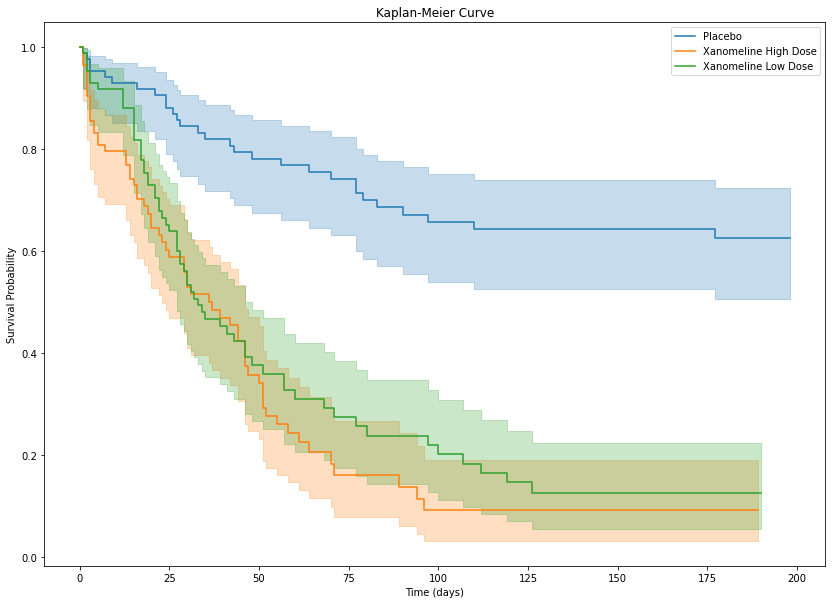

In [122]:
df = data["adtte"].copy()

df = df[
    (df["SAFFL"] == "Y")
].copy()

df["event"] = 1 - df["CNSR"] # censor

kmf = KaplanMeierFitter()

plt.figure(figsize=(14,10))

for trt in df["TRTA"].unique():

    d = df[df["TRTA"] == trt]

    kmf.fit(
        durations=d["AVAL"],
        event_observed=d["event"],
        label=trt
    )

    kmf.plot_survival_function()

plt.title("Kaplan-Meier Curve")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

### Median Survival

- This is the same time point of Median survival time and survival probability

- 다르게 해석하면 전체 환자의 50%가 event를 경험한 시점

In [85]:
median_table = []

for trt in df["TRTA"].unique():

    d = df[df["TRTA"] == trt]

    kmf.fit(d["AVAL"], d["event"])

    median_table.append({
        "Treatment": trt,
        "Median Survival": kmf.median_survival_time_
    })

median_table = pd.DataFrame(median_table)

print(median_table)

              Treatment  Median Survival
0               Placebo              inf
1  Xanomeline High Dose             36.0
2   Xanomeline Low Dose             33.0


- Placebo: Median not reached
    - survival curve가 0.5 이하로 떨어지지 않았다
    - follow-up 기간 동안 50% 이상의 환자가 event를 경험하지 않았다
- Xanomeline High Dose: 36
    - 50%의 환자가 event를 경험한 시점 = 36일
- Xanomeline Low Dose: 33
    - 50% event 발생 시점 = 33일

### Cox model

In [123]:
df_model = df[["AVAL","event","TRTA","AGE","SEX"]].copy()

df_model = pd.get_dummies(df_model, columns=["TRTA","SEX"], drop_first=True)

cph = CoxPHFitter()

cph.fit(
    df_model,
    duration_col="AVAL",
    event_col="event"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 254 total observations, 102 right-censored observations>
             duration col = 'AVAL'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 254
number of events observed = 152
   partial log-likelihood = -718.29
         time fit was run = 2026-03-08 15:18:16 UTC

---
                            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                         
AGE                        -0.01       0.99       0.01            -0.03             0.00                 0.97                 1.00
TRTA_Xanomeline High Dose   1.63       5.13       0.23             1.17             2.10                 3.24                 8.13
TRTA_Xanomeline Low Dose    1.50       4.47       0.23             1.04             1.95                 2.84                 7.06
SEX_M                       0.38       1.46       0.17             0.06             0.70                 1.06                 2.02

                            cmp to     z      p   -log2(p)
covariate                                                 
AGE                           0.00 -1.56   0.12       3.09
TRTA_Xanomeline High Dose     0.00  6.96 <0.005      38.12
TRTA_Xanomeline Low Dose      0.00  6.44 <0.005      33.00
SEX_M                         0.00  2.31   0.02       5.57
---
Concordance = 0.68
Partial AIC = 1444.58
log-likelihood ratio test = 72.06 on 4 df
-log2(p) of ll-ratio test = 46.77

- Hazard Ratio

In [126]:
cph.summary[["exp(coef)","exp(coef) lower 95%","exp(coef) upper 95%","p"]].round(2)

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
AGE,0.99,0.97,1.00,0.12
TRTA_Xanomeline High Dose,5.13,3.24,8.13,0.00
TRTA_Xanomeline Low Dose,4.47,2.84,7.06,0.00
SEX_M,1.46,1.06,2.02,0.02


- High dose group event risk = placebo 대비 5.13배 event가 훨씬 빨리 발생
- Low dose group event risk = placebo 대비 4.47배 event 발생 위험 증가
- 남성 event risk = 여성 대비 1.46배

- In the Cox proportional hazards model, both Xanomeline treatment groups showed significantly higher hazards of the event compared with placebo (HR=5.13 for the high-dose group and HR=4.47 for the low-dose group, both p<0.001). Male subjects also showed a higher hazard of the event compared with females (HR=1.46, p=0.02). Age was not significantly associated with the hazard of the event.

- Cox 비례위험모형 분석 결과 Xanomeline 고용량군과 저용량군 모두 위약군에 비해 이벤트 발생 위험이 유의하게 높게 나타났다(고용량군 HR=5.13, 저용량군 HR=4.47, 모두 p<0.001). 또한 남성은 여성에 비해 이벤트 발생 위험이 유의하게 높았다(HR=1.46, p=0.02). 반면 나이는 이벤트 발생 위험과 유의한 관련성을 보이지 않았다.

In [129]:
placebo = df[df["TRTA"]=="Placebo"]
high = df[df["TRTA"]=="Xanomeline High Dose"]
low = df[df["TRTA"]=="Xanomeline Low Dose"]

results = logrank_test(
    placebo["AVAL"],
    high["AVAL"],
    placebo["event"],
    high["event"]
)

results2 = logrank_test(
    placebo["AVAL"],
    low["AVAL"],
    placebo["event"],
    low["event"]
)

print('--high dose--')
print(results.summary)
print('--low dose--')
print(results2.summary)

--high dose--
   test_statistic             p   -log2(p)
0       52.327004  4.698686e-13  40.952808
--low dose--
   test_statistic             p   -log2(p)
0       42.141114  8.491892e-11  33.455123


- Placebo vs High/Low Dose survival curve 차이 있음

- Kaplan–Meier analysis showed clear separation between treatment groups. Log-rank tests indicated statistically significant differences in survival distributions between placebo and both Xanomeline treatment groups (p < 0.001). These findings were consistent with the Cox proportional hazards model, which showed significantly higher hazards of the event in the treatment groups compared with placebo.

- Kaplan–Meier 분석에서 치료군 간 생존곡선이 명확히 분리되는 양상이 관찰되었다. Log-rank 검정 결과 위약군과 Xanomeline 치료군 간 생존분포에 통계적으로 유의한 차이가 나타났다(p < 0.001). 이러한 결과는 치료군에서 이벤트 발생 위험이 유의하게 높게 나타난 Cox 비례위험모형 결과와 일관된 결과이다.

---

- Kaplan–Meier methods were used to estimate the survival curves for each treatment group. Median time to event was calculated along with 95% confidence intervals. Treatment effects were further evaluated using a Cox proportional hazards model.

- Kaplan–Meier 방법을 사용하여 각 치료군의 생존 곡선을 추정하였다. 이벤트 발생까지의 중앙값과 95% 신뢰구간을 계산하였으며, 치료 효과는 Cox 비례위험모형을 이용하여 추가적으로 평가하였다.

---